In [ ]:
# import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries Loaded Successfully!")


Hello HomeWorth AI 🚀
All Libraries Loaded Successfully!


In [13]:
# Load the Dataset

df = pd.read_excel("../Dataset/House_Price_Prediction_Dataset.xlsx")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [14]:
# Display first 5 rows

df.head()

,House_ID,City,Locality,Locality_Type,Property_Type,Area_sqft,Bedrooms,Bathrooms,Balconies,Floor_No,...,Has_Swimming_Pool,Has_Garden,Has_Power_Backup,Has_Clubhouse,Amenities_Score,Ownership_Type,Transaction_Type,Listing_Type,Months_on_Market,Price_Lakhs
0,H0001,Mumbai,Green Park,Suburban,Apartment,300.0,2,1.0,1,3,...,0,0,1,1,4,Co-operative Society,Resale,Owner,18,30.54
1,H0002,Ahmedabad,Riverside,Suburban,Apartment,1774.0,3,3.0,3,6,...,0,1,0,1,5,Leasehold,Resale,Broker,12,89.99
2,H0003,Chennai,Sector 12,Urban,Apartment,1404.0,3,3.0,0,0,...,0,1,1,1,5,Freehold,Resale,Owner,21,81.15
3,H0004,Lucknow,Sector 12,Urban,Apartment,300.0,3,3.0,3,8,...,0,1,1,0,3,Co-operative Society,Resale,Broker,10,14.76
4,H0005,Lucknow,Riverside,Urban,Villa,1366.0,2,1.0,1,7,...,0,0,1,0,3,Freehold,New Booking,Owner,15,88.84


In [15]:
# Check Dataset Shape

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 506
Number of Columns: 34


In [16]:
# Display all column names

print(df.columns.tolist())

['House_ID', 'City', 'Locality', 'Locality_Type', 'Property_Type', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Balconies', 'Floor_No', 'Total_Floors', 'Age_of_Property_Years', 'Furnishing_Status', 'Parking_Spaces', 'Facing', 'Distance_to_City_Center_km', 'Nearby_Schools_Count', 'Nearby_Hospitals_Count', 'Public_Transport_Access', 'Crime_Rate_Index', 'Air_Quality_Index', 'Has_Lift', 'Has_Security', 'Has_Gym', 'Has_Swimming_Pool', 'Has_Garden', 'Has_Power_Backup', 'Has_Clubhouse', 'Amenities_Score', 'Ownership_Type', 'Transaction_Type', 'Listing_Type', 'Months_on_Market', 'Price_Lakhs']


In [17]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    506 non-null    object 
 1   City                        506 non-null    object 
 2   Locality                    506 non-null    object 
 3   Locality_Type               506 non-null    object 
 4   Property_Type               506 non-null    object 
 5   Area_sqft                   496 non-null    float64
 6   Bedrooms                    506 non-null    int64  
 7   Bathrooms                   497 non-null    float64
 8   Balconies                   506 non-null    int64  
 9   Floor_No                    506 non-null    int64  
 10  Total_Floors                506 non-null    int64  
 11  Age_of_Property_Years       491 non-null    float64
 12  Furnishing_Status           496 non-null    object 
 13  Parking_Spaces              506 non

In [18]:
# Check Missing Values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values)

Area_sqft                10
Bathrooms                 9
Age_of_Property_Years    15
Furnishing_Status        10
Crime_Rate_Index         10
Air_Quality_Index        10
Price_Lakhs              10
dtype: int64


In [19]:
# Check Duplicate Records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Phase 2: Data Cleaning

df_clean = df.copy()

print("Working on a copy of the dataset.")

Working on a copy of the dataset.


In [ ]:
## Step 1 : Remove Missing Target Values

df_clean = df_clean.dropna(subset=["Price_Lakhs"])

print("Dataset Shape after removing missing target values:", df_clean.shape)

Dataset Shape after removing missing target values: (496, 34)


In [ ]:
## Step 2 : Handle Missing Values

# Numerical Columns
df_clean["Area_sqft"] = df_clean["Area_sqft"].fillna(df_clean["Area_sqft"].median())
df_clean["Bathrooms"] = df_clean["Bathrooms"].fillna(df_clean["Bathrooms"].median())
df_clean["Age_of_Property_Years"] = df_clean["Age_of_Property_Years"].fillna(df_clean["Age_of_Property_Years"].median())
df_clean["Crime_Rate_Index"] = df_clean["Crime_Rate_Index"].fillna(df_clean["Crime_Rate_Index"].median())
df_clean["Air_Quality_Index"] = df_clean["Air_Quality_Index"].fillna(df_clean["Air_Quality_Index"].median())

# Categorical Column
df_clean["Furnishing_Status"] = df_clean["Furnishing_Status"].fillna(df_clean["Furnishing_Status"].mode()[0])

print("✅ Missing values handled successfully!")

✅ Missing values handled successfully!


In [25]:
print(df_clean.isnull().sum())

House_ID                      0
City                          0
Locality                      0
Locality_Type                 0
Property_Type                 0
Area_sqft                     0
Bedrooms                      0
Bathrooms                     0
Balconies                     0
Floor_No                      0
Total_Floors                  0
Age_of_Property_Years         0
Furnishing_Status             0
Parking_Spaces                0
Facing                        0
Distance_to_City_Center_km    0
Nearby_Schools_Count          0
Nearby_Hospitals_Count        0
Public_Transport_Access       0
Crime_Rate_Index              0
Air_Quality_Index             0
Has_Lift                      0
Has_Security                  0
Has_Gym                       0
Has_Swimming_Pool             0
Has_Garden                    0
Has_Power_Backup              0
Has_Clubhouse                 0
Amenities_Score               0
Ownership_Type                0
Transaction_Type              0
Listing_

# Phase 3 : Exploratory Data Analysis (EDA)

# EDA helps us understand the distribution of data, identify patterns, detect outliers, and discover relationships between different features before building machine learning models.

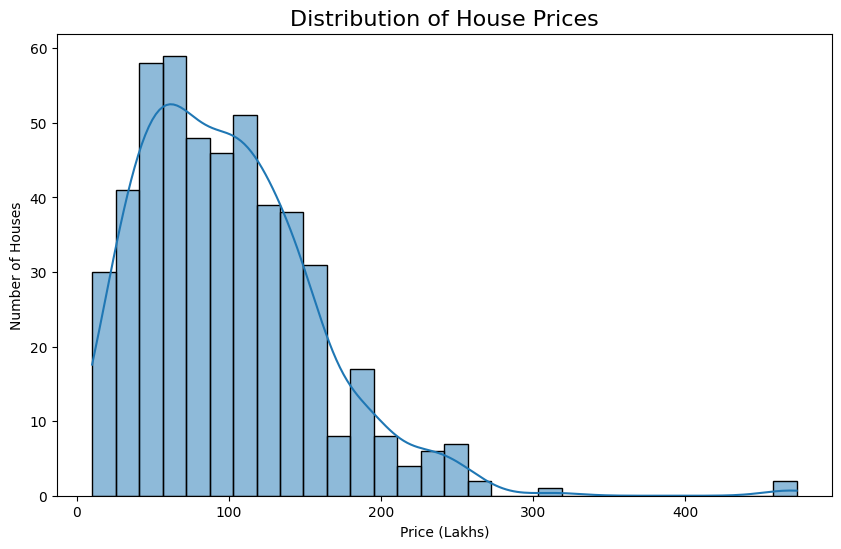

In [26]:
# Price Distribution

plt.figure(figsize=(10,6))

sns.histplot(df_clean["Price_Lakhs"], bins=30, kde=True)

plt.title("Distribution of House Prices", fontsize=16)
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Houses")

plt.show()

### Observation

# - Most houses are concentrated within a specific price range.
# - Very high-priced houses are fewer in number.
# - This helps us understand whether the target variable is normally distributed or skewed.

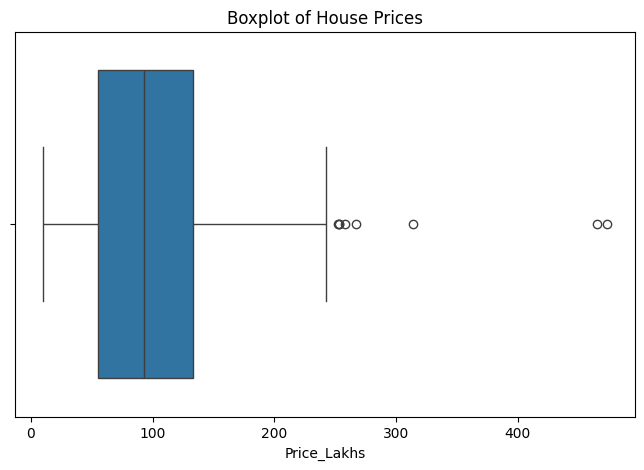

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean["Price_Lakhs"])

plt.title("Boxplot of House Prices")

plt.show()

### Observation

# - Boxplots help identify outliers.
# - Outliers represent extremely expensive or unusually cheap properties.
# - We will decide later whether to keep or remove them.

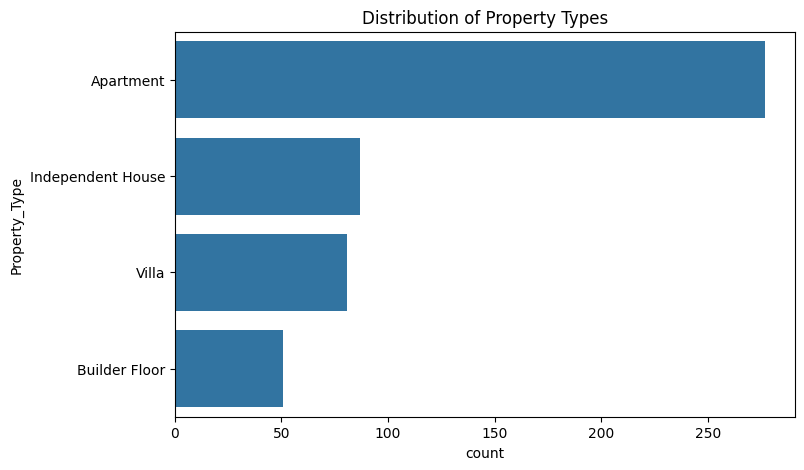

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=df_clean["Property_Type"],
    order=df_clean["Property_Type"].value_counts().index
)

plt.title("Distribution of Property Types")

plt.show()

### Observation

# - The chart shows the number of houses available for each property type.
# - This helps understand the composition of the dataset.

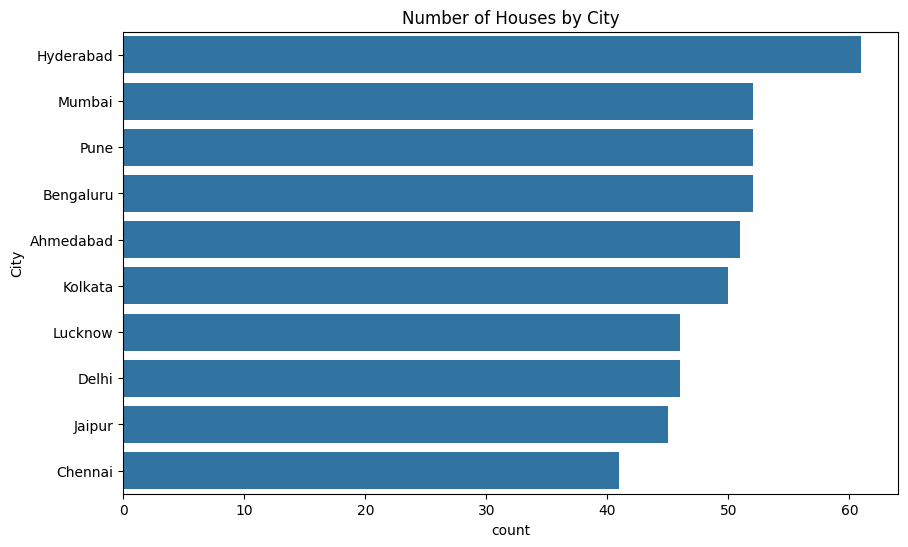

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df_clean["City"],
    order=df_clean["City"].value_counts().index
)

plt.title("Number of Houses by City")

plt.show()

### Observation

# - Some cities have significantly more property listings than others.
# - This indicates where the dataset is more heavily represented.

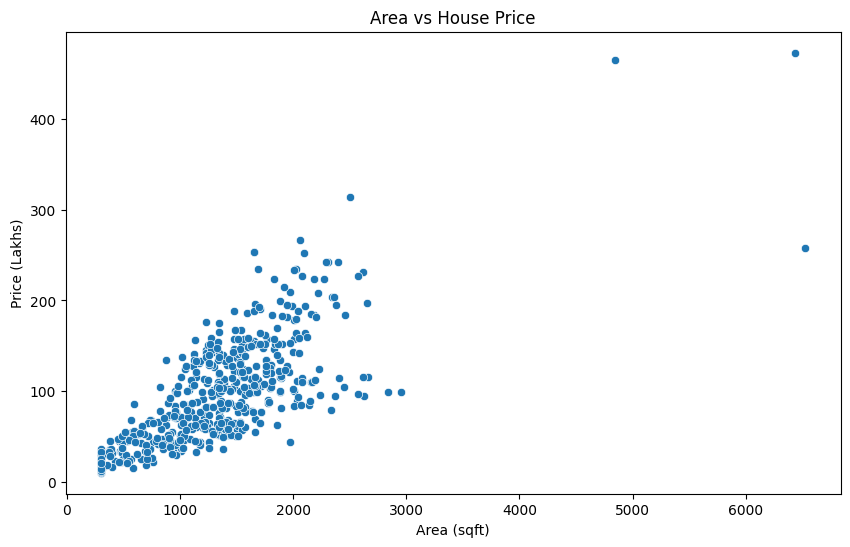

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Area_sqft",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")

plt.show()

### Observation

# - House prices generally increase as the area increases.
# - A positive relationship exists between Area and Price.
# - Area is expected to be one of the most important features for prediction.

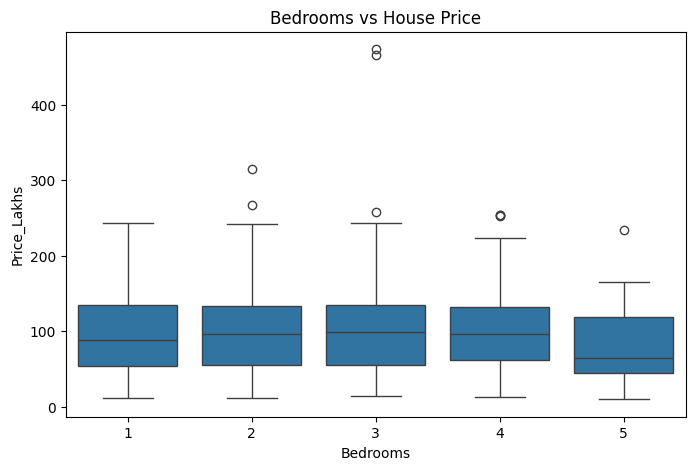

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Bedrooms",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("Bedrooms vs House Price")

plt.show()

### Observation

# - Houses with more bedrooms generally have higher prices.
# - Some overlap exists because other factors also influence price.

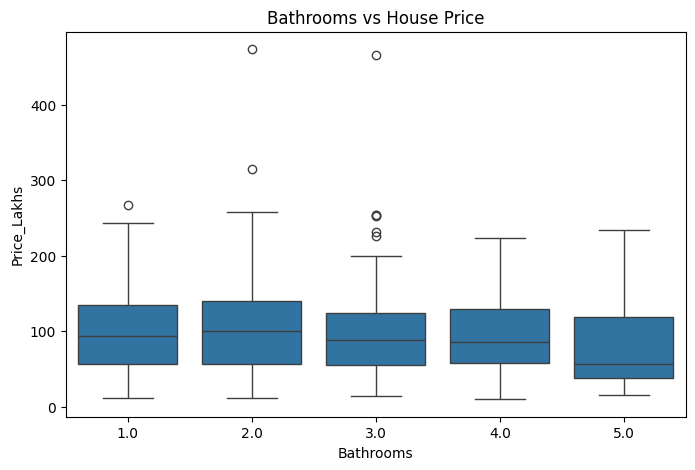

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Bathrooms",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("Bathrooms vs House Price")

plt.show()

### Observation

# - Houses with more bathrooms generally have higher prices.
# - Some overlap exists because other factors also influence price.

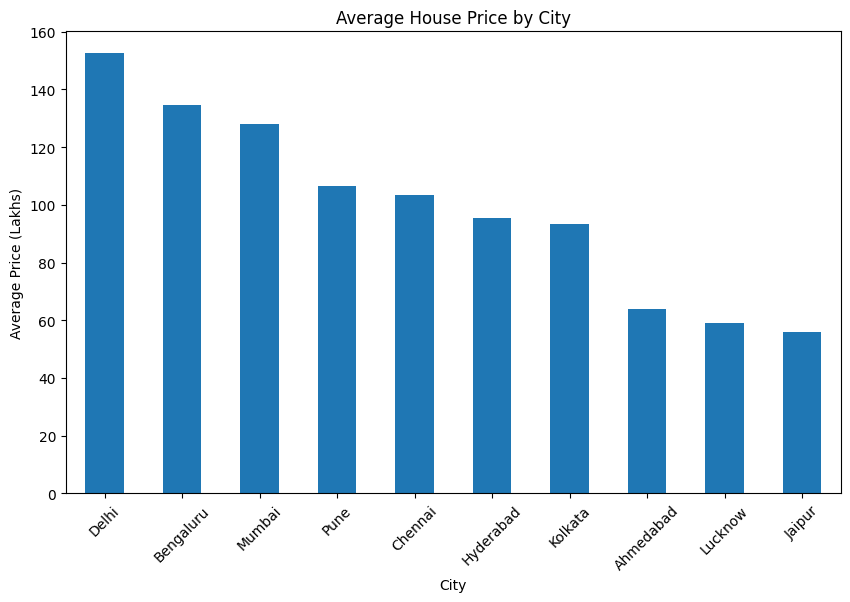

In [33]:
city_price = (
    df_clean.groupby("City")["Price_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

city_price.plot(kind="bar")

plt.title("Average House Price by City")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=45)

plt.show()

### Observation

# - Some cities have a significantly higher average property price.
# - Location is therefore an important factor in price prediction.

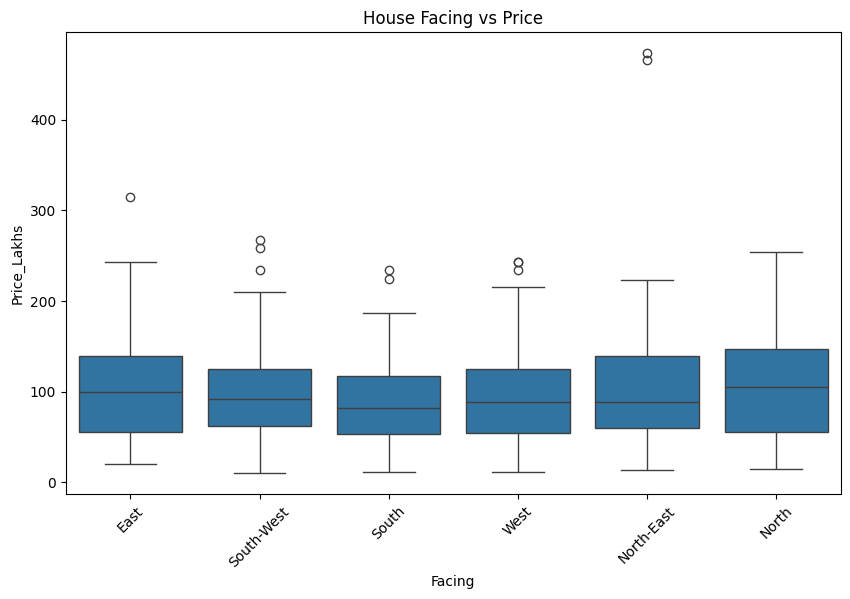

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Facing",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("House Facing vs Price")
plt.xticks(rotation=45)

plt.show()

### Observation

# - Different facing directions show slight variations in price.
# - This supports including 'Facing' as an input feature in the prediction app.

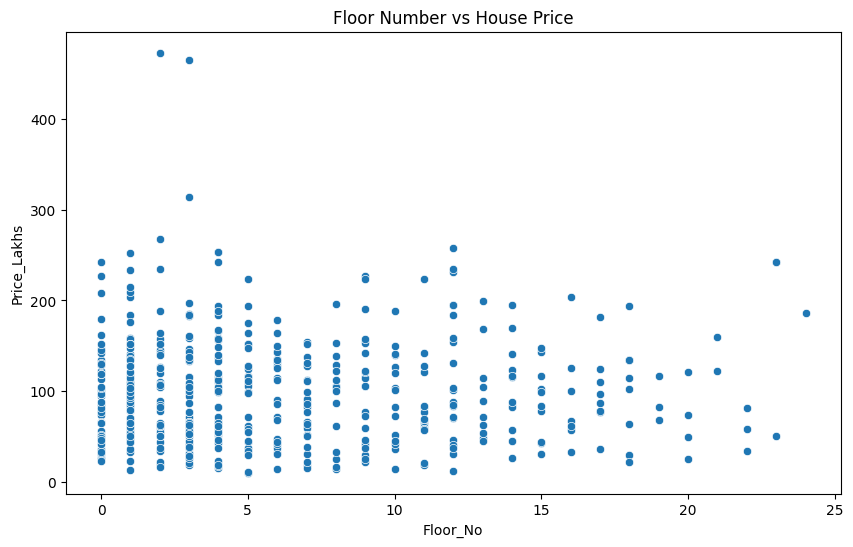

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Floor_No",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("Floor Number vs House Price")

plt.show()

### Observation

# - Floor number has a moderate influence on price.
# - Premium apartments on preferred floors may have higher market value.

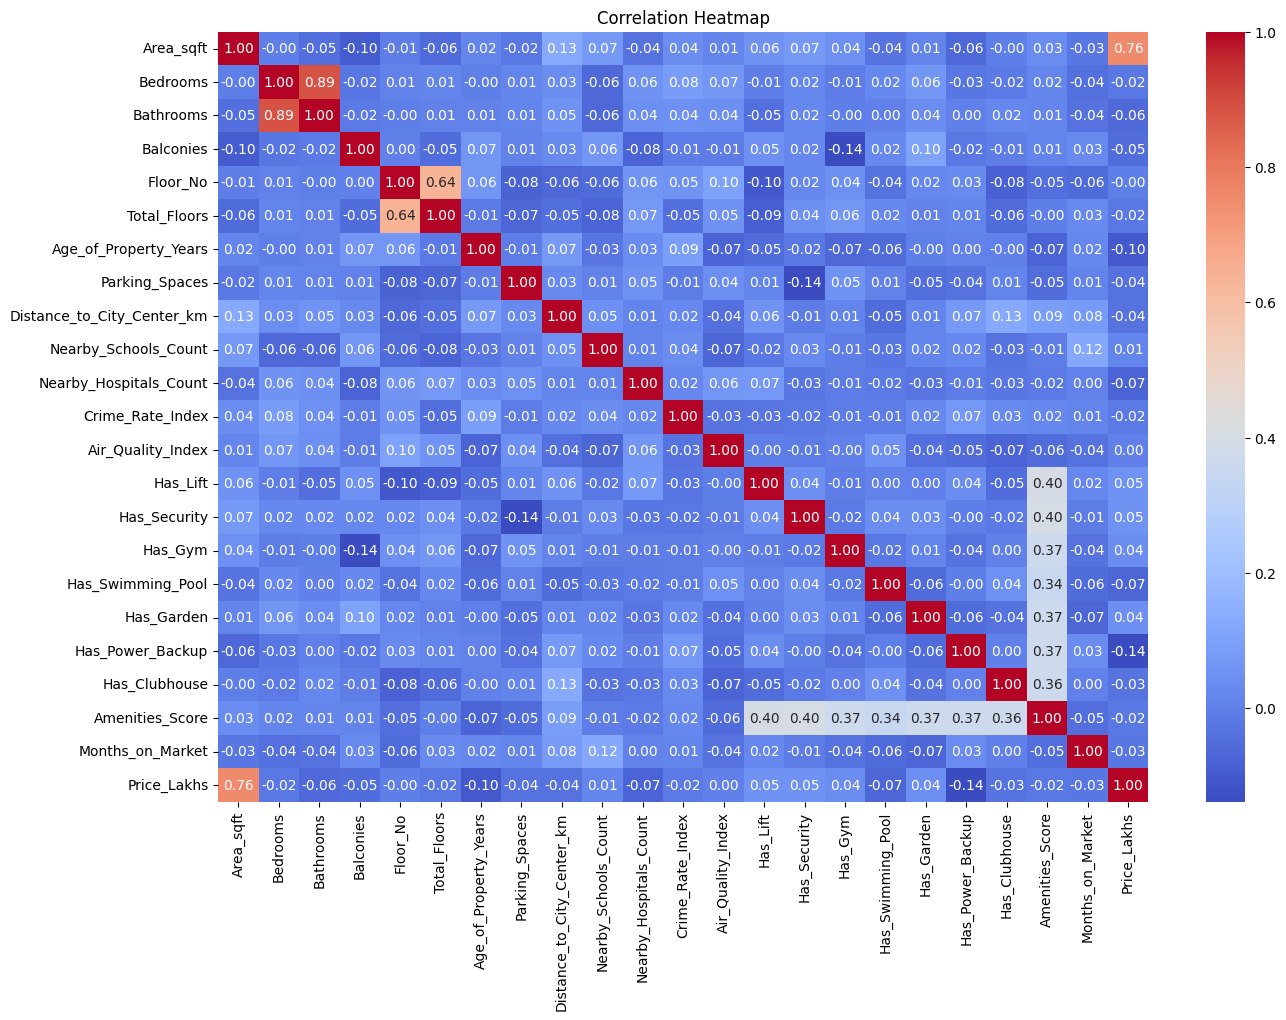

In [36]:
plt.figure(figsize=(15,10))

corr = df_clean.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The correlation heatmap shows the relationship between all numerical features.
- Correlation values range from **-1 to +1**.
- Features with values closer to **+1** have a strong positive relationship, while values closer to **-1** indicate a strong negative relationship.
- Features with values near **0** have little or no linear relationship.
- The heatmap helps identify the most influential features for predicting house prices and also reveals any highly correlated features that may introduce multicollinearity.

### Business Insight

- Features showing a strong positive correlation with **Price_Lakhs** are likely to have the greatest impact on the final prediction.
- Understanding these relationships helps in selecting the most relevant features, improving model accuracy, and making the prediction system more reliable.

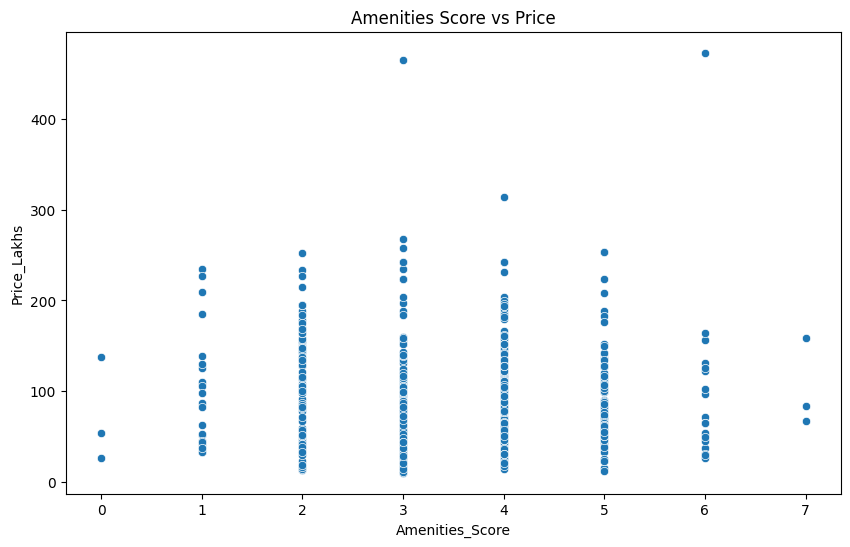

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Amenities_Score",
    y="Price_Lakhs",
    data=df_clean
)

plt.title("Amenities Score vs Price")

plt.show()

### Observation

# - Houses with higher amenities generally command higher prices.
# - Amenities contribute positively to property valuation.

# Phase 4 : Feature Engineering & Data Preprocessing

In this phase, we prepare the dataset for machine learning by selecting relevant features, removing unnecessary columns, encoding categorical variables, and splitting the dataset into training and testing sets.

## Step 1 : Removing Unnecessary Features

The **House_ID** column is a unique identifier assigned to each property. Since it does not influence the house price, it is removed before training the machine learning model.

In [38]:
# Remove unnecessary columns

df_model = df_clean.drop(columns=["House_ID"])

print("Dataset Shape :", df_model.shape)

Dataset Shape : (496, 33)


## Step 2 : Feature and Target Separation

The dataset is divided into:

- Features (X): Input variables used for prediction.
- Target (y): House price (Price_Lakhs), which the model will predict.

In [39]:
X = df_model.drop("Price_Lakhs", axis=1)

y = df_model["Price_Lakhs"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (496, 32)
Target Shape : (496,)


## Step 3 : Identifying Feature Types

Machine learning algorithms require numerical input. Therefore, we first identify numerical and categorical columns so that appropriate preprocessing techniques can be applied.

In [40]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features\n")
print(numerical_features)

print("\nCategorical Features\n")
print(categorical_features)

Numerical Features

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Balconies', 'Floor_No',
       'Total_Floors', 'Age_of_Property_Years', 'Parking_Spaces',
       'Distance_to_City_Center_km', 'Nearby_Schools_Count',
       'Nearby_Hospitals_Count', 'Crime_Rate_Index', 'Air_Quality_Index',
       'Has_Lift', 'Has_Security', 'Has_Gym', 'Has_Swimming_Pool',
       'Has_Garden', 'Has_Power_Backup', 'Has_Clubhouse', 'Amenities_Score',
       'Months_on_Market'],
      dtype='object')

Categorical Features

Index(['City', 'Locality', 'Locality_Type', 'Property_Type',
       'Furnishing_Status', 'Facing', 'Public_Transport_Access',
       'Ownership_Type', 'Transaction_Type', 'Listing_Type'],
      dtype='object')


## 📌 Step 4: Encoding Categorical Features

Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical representations using **One-Hot Encoding**.

To efficiently preprocess both numerical and categorical features, a **ColumnTransformer** is used.

This approach ensures:
- Numerical features remain unchanged.
- Categorical features are encoded automatically.
- The same preprocessing is reused during model training and prediction.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("✅ Preprocessor Created Successfully!")

✅ Preprocessor Created Successfully!


## 📌 Step 5: Train-Test Split

The dataset is divided into two parts:

- Training Set (80%) – Used to train the machine learning model.
- Testing Set (20%) – Used to evaluate the model's performance on unseen data.

This ensures that the model generalizes well to new data.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (396, 32)
Testing Data : (100, 32)


# 🚀 Phase 5 : Model Building

In this phase, three regression algorithms are trained and evaluated to predict house prices. The performance of each model is compared using standard regression metrics, and the best-performing model is selected for deployment.

In [43]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [44]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )

}

In [45]:
results = []

best_model = None
best_score = -1

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    if r2 > best_score:
        best_score = r2
        best_model = pipeline

In [46]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,10.008400,13.854621,0.939177
0,Linear Regression,13.793032,18.420110,0.892487
1,Random Forest,15.857320,21.997630,0.846670


In [47]:
print("🏆 Best Model Selected Successfully!")
print()

print(results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0])

🏆 Best Model Selected Successfully!

Model       Gradient Boosting
MAE                   10.0084
RMSE                13.854621
R2 Score             0.939177
Name: 2, dtype: object


## 📊 Model Comparison

Three regression models were trained and evaluated using MAE, RMSE, and R² Score.

### Results

| Model | R² Score | Performance |
|--------|----------|-------------|
| Linear Regression | 0.892 | Good |
| Random Forest Regressor | 0.847 | Moderate |
| Gradient Boosting Regressor | **0.939** | **Best** |

### Conclusion

Among the three algorithms, **Gradient Boosting Regressor** achieved the highest R² Score and the lowest prediction error (MAE and RMSE). Therefore, it was selected as the final model for deployment in the House Price Prediction System.

# 🚀 Phase 6 : Model Saving

The best-performing machine learning pipeline is saved using the Joblib library. Saving the entire pipeline ensures that both preprocessing and prediction steps are preserved for deployment.

In [48]:
import joblib
import os

# Create Model folder if it doesn't exist
os.makedirs("../Model", exist_ok=True)

# Save the complete pipeline
joblib.dump(best_model, "../Model/house_price_pipeline.pkl")

print("✅ Pipeline saved successfully!")

✅ Pipeline saved successfully!


In [49]:
import os

print(os.listdir("../Model"))

['house_price_pipeline.pkl']


Testing

In [55]:
import joblib

pipeline = joblib.load("../Model/house_price_pipeline.pkl")

print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [56]:
print(pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Locality', 'Locality_Type', 'Property_Type',
       'Furnishing_Status', 'Facing', 'Public_Transport_Access',
       'Ownership_Type', 'Transaction_Type', 'Listing_Type'],
      dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])


In [57]:
categorical_columns = [
    "City",
    "Locality",
    "Locality_Type",
    "Property_Type",
    "Furnishing_Status",
    "Facing",
    "Public_Transport_Access",
    "Ownership_Type",
    "Transaction_Type",
    "Listing_Type"
]

for col in categorical_columns:
    print(f"\n{col}")
    print("-" * 40)
    print(sorted(df_clean[col].dropna().unique()))


City
----------------------------------------
['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Pune']

Locality
----------------------------------------
['Civil Lines', 'Green Park', 'Hill View', 'Lake View', 'MG Road', 'New Extension', 'Old Town', 'Riverside', 'Sector 12', 'Tech Park Road']

Locality_Type
----------------------------------------
['Rural', 'Suburban', 'Urban']

Property_Type
----------------------------------------
['Apartment', 'Builder Floor', 'Independent House', 'Villa']

Furnishing_Status
----------------------------------------
['Fully-Furnished', 'Semi-Furnished', 'Unfurnished']

Facing
----------------------------------------
['East', 'North', 'North-East', 'South', 'South-West', 'West']

Public_Transport_Access
----------------------------------------
['High', 'Low', 'Medium']

Ownership_Type
----------------------------------------
['Co-operative Society', 'Freehold', 'Leasehold']

Transaction_Type
------

In [58]:
print(sorted(df_clean["Public_Transport_Access"].unique()))

['High', 'Low', 'Medium']


In [59]:
print(sorted(df_clean["Ownership_Type"].unique()))
print(sorted(df_clean["Transaction_Type"].unique()))
print(sorted(df_clean["Listing_Type"].unique()))

['Co-operative Society', 'Freehold', 'Leasehold']
['New Booking', 'Resale']
['Broker', 'Owner']
